# Análise comparativa — Liebherr × Hyundai

Confronto detalhado dos custos de máquinas **Liebherr** e **Hyundai** a partir da aba **`base_maquinas_2025_2026`** em `02-Referencias/Custos-Maquinas/relatorio_marcas_maquinas_base.xlsx` (base consolidada 2025+2026, marcas categorizadas e `valor_conta` já tratado).

## Perguntas que esta análise responde
1. **Volume:** qual marca consome mais em `valor_conta` (total, por lançamento, por máquina)?
2. **Tipo:** a diferença vem de manutenção, combustível, peças ou frete?
3. **Onde:** divisão, filial e ativo (`n4_centro_custo`) que concentram o gasto?
4. **Quando:** evolução mensal, **por ano** (2025 e 2026 separados) e gasto de **cada máquina por mês**?
5. **Parque:** médias com **7 Liebherr** e **16 Hyundai** (não usar `nunique` de CC).

## Fluxo da análise (execute em ordem)
| Passo | Seção | O que faz |
|-------|--------|-----------|
| 0 | Configuração | Caminhos, marcas-alvo e filtro opcional de ano |
| 1 | Carga e higiene | Lê `base_maquinas_2025_2026` e filtra Liebherr/Hyundai |
| 2 | Painel executivo | KPIs lado a lado (volume, máquinas, ticket médio) |
| 3 | Composição por conta | Plano de contas e DE-PARA de custeio |
| 4 | Por máquina e divisão | Ranking de ativos e unidades de negócio |
| 5 | Série temporal | Gasto mensal e comparativo ano a ano |
| 6 | Distribuição e Pareto | Gasto mensal por máquina e concentração 80/20 |
| 7 | Gráficos | Visualizações exportadas para `outputs/figuras/` |
| 8 | Síntese | Insights automáticos + planilha de resumo |
| 9 | LaTeX | Gera `.tex` do relatório executivo para PDF |

> **Comparativo justo entre marcas:** gráficos Liebherr × Hyundai usam **custo médio por máquina** (gasto total do parque ÷ 7 ou ÷ 16), não totais brutos — senão Hyundai parece sempre mais cara só por ter mais máquinas.
> **Métrica base:** `gasto_abs = |valor_conta|`; agregações do parque usam só lançamentos com `maq_id` em `PARQUE_MAQUINAS`.

## Passo 0 — Configuração

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ── Parâmetros (ajuste aqui) ───────────────────────────────────────────────
MARCAS_ALVO = ["LIEBHERR", "HYUNDAI"]
SHEET_ENTRADA = "base_maquinas_2025_2026"  # única aba utilizada nesta análise
ANO_FILTRO: list[int] | None = None  # ex.: [2026] para só 2026; None = 2025+2026

# Contas excluídas dos gráficos (ISS = imposto municipal, não custo operacional)
CONTAS_EXCLUIR_GRAFICOS: frozenset[str] = frozenset({"7.4.5"})

# Parque oficial (médias e custo/máquina usam estas quantidades, não nunique do CC)
PARQUE_MAQUINAS: dict[str, list[str]] = {
    "LIEBHERR": [
        "EHL0013", "EHL0014", "EHL0028", "EHL0041", "EHL0042", "EHL0043", "EHL0070",
    ],
    "HYUNDAI": [
        "EHH0002", "EHH0003", "EHH0004", "EHH0006", "EHH0007", "EHH0008", "EHH0009",
        "EHH0015", "EHH0019", "EHH0036", "EHH0037", "EHH0038", "EHH0039", "EHH0040",
        "EHH0044", "EHH0046",
    ],
}
QTD_PARQUE = {m: len(ids) for m, ids in PARQUE_MAQUINAS.items()}

# Local operacional (fonte: diretor financeiro, jun/2026) — cruzado com CC na base
LOCAL_POR_MAQUINA: dict[str, str] = {
    "EHH0006": "Prudente", "EHH0009": "Prudente",
    "EHH0002": "Maringá", "EHH0004": "Maringá", "EHH0039": "Maringá",
    "EHH0008": "Londrina", "EHH0040": "Londrina",
    "EHH0036": "Dourados", "EHH0044": "Dourados",
    "EHH0038": "Campo Grande", "EHH0046": "Campo Grande",
    "EHH0015": "Ambar", "EHH0019": "Ambar",
    "EHH0003": "Tupy", "EHH0007": "Matheus", "EHH0037": "Multi Aço",
    "EHL0028": "Prudente",
    "EHL0043": "Maringá", "EHL0070": "Maringá",
    "EHL0042": "Dourados", "EHL0041": "Tupy",
    "EHL0013": "Pátio de Manutenção", "EHL0014": "Pátio de Manutenção",
}
ORDEM_LOCAIS = [
    "Prudente", "Maringá", "Londrina", "Dourados", "Campo Grande",
    "Ambar", "Tupy", "Pátio de Manutenção", "Matheus", "Multi Aço",
]
# ────────────────────────────────────────────────────────────────────────────

NOTEBOOK_DIR = Path.cwd()
_candidatos = [
    NOTEBOOK_DIR / ".." / "02-Referencias" / "Custos-Maquinas",
    NOTEBOOK_DIR / "02-Referencias" / "Custos-Maquinas",
    Path("02-Referencias") / "Custos-Maquinas",
]
CUSTOS_DIR = next((p.resolve() for p in _candidatos if p.resolve().exists()), None)
if CUSTOS_DIR is None:
    raise FileNotFoundError("Pasta 02-Referencias/Custos-Maquinas não encontrada.")

ROOT = CUSTOS_DIR.parent.parent if CUSTOS_DIR.name == "Custos-Maquinas" else CUSTOS_DIR.parent
ARQUIVO = CUSTOS_DIR / "relatorio_marcas_maquinas_base.xlsx"
OUT_TAB = ROOT / "outputs" / "tabelas"
OUT_FIG = ROOT / "outputs" / "figuras" / "liebherr_hyundai"
OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

CORES = {"LIEBHERR": "#F4C430", "HYUNDAI": "#004B8D"}

if not ARQUIVO.exists():
    raise FileNotFoundError(ARQUIVO)

if SHEET_ENTRADA not in pd.ExcelFile(ARQUIVO).sheet_names:
    raise ValueError(
        f"Aba obrigatória {SHEET_ENTRADA!r} não encontrada em {ARQUIVO.name}. "
        "Regenere o arquivo com relatorio_marcas_maquinas.ipynb."
    )

print(f"Arquivo: {ARQUIVO.resolve()}")
print(f"Aba:     {SHEET_ENTRADA}")
print(f"Marcas:  {MARCAS_ALVO}")
for m in MARCAS_ALVO:
    print(f"  Parque {m}: {QTD_PARQUE[m]} máquinas")

Arquivo: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Custos-Maquinas\relatorio_marcas_maquinas_base.xlsx
Aba:     base_maquinas_2025_2026
Marcas:  ['LIEBHERR', 'HYUNDAI']
  Parque LIEBHERR: 7 máquinas
  Parque HYUNDAI: 16 máquinas


## Passo 1 — Carga e filtro de marcas

Leitura exclusiva de **`base_maquinas_2025_2026`**. Cada lançamento é vinculado a um **`maq_id`** (ex.: `EHL0043`) extraído de `n4_centro_custo`, evitando duplicar a mesma máquina em CCs diferentes. O parque oficial é **7 Liebherr** e **16 Hyundai** (`PARQUE_MAQUINAS`).

In [2]:
def col_por_prefixo(df: pd.DataFrame, prefixo: str) -> str | None:
    hits = [c for c in df.columns if str(c).upper().startswith(prefixo.upper())]
    return hits[0] if hits else None


def extrair_id_maquina(valor) -> str | None:
    """Identificador único da máquina (EHL/EHH), independente do CC analítico."""
    s = re.sub(r"\s+", "", str(valor).strip().upper())
    m = re.match(r"^(EHL\d+|EHH\d+)", s)
    return m.group(1) if m else None


def no_parque(row) -> bool:
    mid = row.get("maq_id")
    if pd.isna(mid):
        return False
    return mid in PARQUE_MAQUINAS.get(row.get("MARCA"), [])


raw = pd.read_excel(ARQUIVO, sheet_name=SHEET_ENTRADA)
raw["valor_conta_num"] = pd.to_numeric(raw["valor_conta"], errors="coerce")
raw["data_nf"] = pd.to_datetime(raw["data_nf"], errors="coerce", dayfirst=True)
raw["data_pagamento"] = pd.to_datetime(raw["data_pagamento"], errors="coerce", dayfirst=True)
raw["maq_id"] = raw["n4_centro_custo"].map(extrair_id_maquina)
raw["ano_nf"] = raw["data_nf"].dt.year
raw["mes_nf"] = raw["data_nf"].dt.to_period("M").astype(str)
raw["gasto_abs"] = raw["valor_conta_num"].abs()
raw["MARCA"] = raw["MARCA"].astype(str).str.strip().str.upper()

COL_DEPARA = col_por_prefixo(raw, "DE-PARA1") or "DE-PARA1"
COL_CUSTEIO = col_por_prefixo(raw, "CUSTEIO VARI") or "CUSTEIO VARIÁVEL"

df = raw[raw["MARCA"].isin(MARCAS_ALVO)].copy()
df["maq_id"] = df["n4_centro_custo"].map(extrair_id_maquina)
df["no_parque"] = df.apply(no_parque, axis=1)
df_maq = df[df["no_parque"]].copy()
if ANO_FILTRO:
    df = df[df["ano_nf"].isin(ANO_FILTRO)].copy()
    df_maq = df_maq[df_maq["ano_nf"].isin(ANO_FILTRO)].copy()

YLABEL_MAQ = "R$ médio / máquina"


def excluir_contas_graficos(d: pd.DataFrame) -> pd.DataFrame:
    """Remove contas de ISS (e similares) — usadas só na base dos gráficos."""
    cod = d["cod_conta"].astype(str).str.strip()
    return d[~cod.isin(CONTAS_EXCLUIR_GRAFICOS)].copy()


df_maq_graf = excluir_contas_graficos(df_maq)


def adicionar_volume_por_maq(tab: pd.DataFrame, col_vol: str = "volume") -> pd.DataFrame:
    out = tab.copy()
    out["volume_por_maq"] = out[col_vol] / out["MARCA"].map(QTD_PARQUE)
    return out


display(Markdown(
    f"**{len(df):,}** lançamentos das marcas {MARCAS_ALVO} "
    f"(de {len(raw):,} na aba `{SHEET_ENTRADA}` — demais marcas ficam fora desta análise)."
))

_vc_marcas = raw["MARCA"].value_counts()
outras_marcas = _vc_marcas[~_vc_marcas.index.isin(MARCAS_ALVO)]
if len(outras_marcas):
    display(Markdown("### Outras marcas na aba (não incluídas no comparativo)"))
    display(outras_marcas.head(10).to_frame("lançamentos"))

display(Markdown("### Parque oficial vs lançamentos com `maq_id` no parque"))
display(pd.DataFrame({
    "marca": MARCAS_ALVO,
    "parque": [QTD_PARQUE[m] for m in MARCAS_ALVO],
    "lanç. no parque": [len(df_maq[df_maq.MARCA == m]) for m in MARCAS_ALVO],
    "maq. com lanç.": [df_maq.loc[df_maq.MARCA == m, "maq_id"].nunique() for m in MARCAS_ALVO],
    "sem maq_id (outros CCs)": [len(df[(df.MARCA == m) & ~df.no_parque]) for m in MARCAS_ALVO],
}))

qualidade = pd.DataFrame(
  {
    "métrica": [
      "Linhas sem valor_conta",
      "Linhas sem data_nf",
      "Linhas sem n4 (máquina)",
      "Linhas valor_conta = 0",
    ],
    "qtd": [
      df["valor_conta_num"].isna().sum(),
      df["data_nf"].isna().sum(),
      df["n4_centro_custo"].isna().sum(),
      (df["valor_conta_num"] == 0).sum(),
    ],
  }
)
display(qualidade)
df.head(3)

**1,463** lançamentos das marcas ['LIEBHERR', 'HYUNDAI'] (de 6,425 na aba `base_maquinas_2025_2026` — demais marcas ficam fora desta análise).

### Outras marcas na aba (não incluídas no comparativo)

,lançamentos
MARCA,
VOLVO,2736
HIDROEUROPA,1033
FORD,532
M. BENZ,226
IMAVI,166
BUSA,74
FIATALLIS,42
VOLKSWAGEN,35
PREMER,29


### Parque oficial vs lançamentos com `maq_id` no parque

,marca,parque,lanç. no parque,maq. com lanç.,sem maq_id (outros CCs)
0,LIEBHERR,7,384,7,2
1,HYUNDAI,16,1063,16,14


,métrica,qtd
0,Linhas sem valor_conta,0
1,Linhas sem data_nf,0
2,Linhas sem n4 (máquina),0
3,Linhas valor_conta = 0,0


,Divisao,n1_cod_centro_custo,n1_centro_custo,n1_CC,n2_cod_centro_custo,n2_centro_custo,n2_CC,n3_cod_centro_custo,n3_centro_custo,n3_CC,n4_cod_centro_custo,n4_centro_custo,n4_CC,MARCA,cod_conta,...,Origem,Sistema,Dados auxiliares,Valor Oficial,MODELO DE QUEBRA MARCONDES 1,MODELO DE QUEBRA MARCONDES 2,DE-PARA1,DE-PARA2,CUSTEIO VARIÁVEL,valor_conta_num,maq_id,ano_nf,mes_nf,gasto_abs,no_parque
0,EKIPA LOCACOES E SERV G&S,1.70,EKIPA LOCACOES E SERV G&S,1.7 EKIPA LOCACOES E SERV G&S,1.7.1,CONTRATOS,1.7.1 CONTRATOS,1.7.1.4,ARCELOR - PIRACICABA/SP,1.7.1.4 ARCELOR - PIRACICABA/SP,1.7.1.4,EHH0002,1.7.1.4 ARCELOR - PIRACICABA/SP,HYUNDAI,7.1.22,...,Saída (Aplicações),Atua,"COMBUSTIVEL - DIESEL;contas_filtro=7.1.1,7.1.2...","-1,145.40",Custo Variável,Operacional,4.01.03 CUSTO COM COMBUSTÍVEL - DIESEL,4.01 CUSTO DA MERCADORIA VENDIDA,4.01 CUSTO FIXO,"1,145.40",EHH0002,2025,2025-01,"1,145.40",True
3,SELETIVA,1.20,SELETIVA,1.2 SELETIVA,1.2.7,CAMPO GRANDE,1.2.7 CAMPO GRANDE,1.2.7.3,OPERACIONAL,1.2.7.3 OPERACIONAL,1.2.7.3,EHH0046,1.2.7.3 OPERACIONAL,HYUNDAI,7.1.22,...,Saída (Aplicações),Atua,"COMBUSTIVEL - DIESEL;contas_filtro=7.1.1,7.1.2...","-1,654.96",Custo Variável,Operacional,4.01.03 CUSTO COM COMBUSTÍVEL - DIESEL,4.01 CUSTO DA MERCADORIA VENDIDA,4.01 CUSTO FIXO,"1,654.96",EHH0046,2025,2025-01,"1,654.96",True
5,SELETIVA,1.20,SELETIVA,1.2 SELETIVA,1.2.7,CAMPO GRANDE,1.2.7 CAMPO GRANDE,1.2.7.3,OPERACIONAL,1.2.7.3 OPERACIONAL,1.2.7.3,EHH0038,1.2.7.3 OPERACIONAL,HYUNDAI,7.1.22,...,Saída (Aplicações),Atua,"COMBUSTIVEL - DIESEL;contas_filtro=7.1.1,7.1.2...","-1,712.17",Custo Variável,Operacional,4.01.03 CUSTO COM COMBUSTÍVEL - DIESEL,4.01 CUSTO DA MERCADORIA VENDIDA,4.01 CUSTO FIXO,"1,712.17",EHH0038,2025,2025-01,"1,712.17",True


## Passo 2 — Painel executivo (KPIs)

Comparativo lado a lado. **Custo médio por máquina** = volume do parque ÷ **7** (Liebherr) ou **16** (Hyundai), com volumes **separados por ano**.

In [3]:
def kpi_marca(d: pd.DataFrame) -> pd.Series:
  marca = d.name  # chave do groupby (include_groups=False remove coluna MARCA)
  qtd_parque = QTD_PARQUE.get(marca, np.nan)
  dm = d[d["no_parque"]]
  lanc = len(d)
  lanc_maq = len(dm)
  soma_liq = d["valor_conta_num"].sum()
  vol = d["gasto_abs"].sum()
  vol_maq = dm["gasto_abs"].sum()
  despesa = d.loc[d["valor_conta_num"] < 0, "valor_conta_num"].sum()
  receita_ajuste = d.loc[d["valor_conta_num"] > 0, "valor_conta_num"].sum()
  maq_com_lanc = dm["maq_id"].nunique()
  return pd.Series(
    {
      "lançamentos (marca)": lanc,
      "lançamentos (parque)": lanc_maq,
      "máquinas no parque": qtd_parque,
      "máquinas com lanç.": maq_com_lanc,
      "soma valor_conta (líquido)": soma_liq,
      "volume gasto (|valor|)": vol,
      "volume parque (|valor|)": vol_maq,
      "despesas (<0)": despesa,
      "ajustes/créditos (>0)": receita_ajuste,
      "ticket médio (|valor|)": d["gasto_abs"].mean(),
      "custo médio/máquina (parque)": vol_maq / qtd_parque if qtd_parque else np.nan,
    }
  )


kpi = df.groupby("MARCA", observed=True).apply(kpi_marca, include_groups=False).T
display(Markdown("### KPIs por marca"))
display(kpi)

if len(MARCAS_ALVO) == 2:
  m1, m2 = MARCAS_ALVO
  c1 = kpi.loc["custo médio/máquina (parque)", m1]
  c2 = kpi.loc["custo médio/máquina (parque)", m2]
  diff_pct = (c1 - c2) / c2 * 100 if c2 else np.nan
  maior = m1 if c1 >= c2 else m2
  display(Markdown(
    f"**Comparativo justo (custo médio/máquina):** {maior} tem custo **{abs(diff_pct):.1f}%** "
    f"{'maior' if diff_pct > 0 else 'menor'} que a outra marca "
    f"({m1} R$ {c1:,.0f}/máq vs {m2} R$ {c2:,.0f}/máq)."
  ))

por_ano = (
  df.groupby(["MARCA", "ano_nf"], observed=True)
  .agg(
    lanc=("valor_conta_num", "count"),
    volume=("gasto_abs", "sum"),
    liquido=("valor_conta_num", "sum"),
  )
  .reset_index()
)
por_ano["parque"] = por_ano["MARCA"].map(QTD_PARQUE)
por_ano_vol_maq = (
  df_maq.groupby(["MARCA", "ano_nf"], observed=True)["gasto_abs"].sum().reset_index(name="volume_parque")
)
por_ano = por_ano.merge(por_ano_vol_maq, on=["MARCA", "ano_nf"], how="left")
por_ano["volume_parque"] = por_ano["volume_parque"].fillna(0)
por_ano["custo_por_maquina_parque"] = por_ano["volume_parque"] / por_ano["parque"]
display(Markdown("### Evolução por ano (data_nf) — volume separado por ano"))
display(por_ano)

### KPIs por marca

MARCA,HYUNDAI,LIEBHERR
lançamentos (marca),"1,077.00",386.00
lançamentos (parque),"1,063.00",384.00
máquinas no parque,16.00,7.00
máquinas com lanç.,16.00,7.00
soma valor_conta (líquido),"-545,063.37","-668,859.37"
volume gasto (|valor|),"1,399,720.45","870,202.59"
volume parque (|valor|),"1,389,933.20","868,502.59"
despesas (<0),"-972,391.91","-769,530.98"
ajustes/créditos (>0),"427,328.54","100,671.61"
ticket médio (|valor|),"1,299.65","2,254.41"


**Comparativo justo (custo médio/máquina):** LIEBHERR tem custo **42.8%** maior que a outra marca (LIEBHERR R$ 124,072/máq vs HYUNDAI R$ 86,871/máq).

### Evolução por ano (data_nf) — volume separado por ano

,MARCA,ano_nf,lanc,volume,liquido,parque,volume_parque,custo_por_maquina_parque
0,HYUNDAI,2025,848,"1,220,373.44","-365,716.36",16,"1,210,586.19","75,661.64"
1,HYUNDAI,2026,229,"179,347.01","-179,347.01",16,"179,347.01","11,209.19"
2,LIEBHERR,2025,292,"733,840.46","-532,497.24",7,"733,840.46","104,834.35"
3,LIEBHERR,2026,94,"136,362.13","-136,362.13",7,"134,662.13","19,237.45"


## Passo 3 — Composição por tipo de gasto (conta e custeio)

Aqui dissecamos **em que rubricas** cada marca gasta — manutenção (`7.1.2`), diesel interno/posto, peças, frete etc.

In [4]:
por_conta = (
  df_maq.groupby(["MARCA", "cod_conta", "conta"], observed=True)
  .agg(qtd=("valor_conta_num", "count"), liquido=("valor_conta_num", "sum"), volume=("gasto_abs", "sum"))
  .reset_index()
  .sort_values(["MARCA", "volume"], ascending=[True, False])
)
por_conta = adicionar_volume_por_maq(por_conta)
display(Markdown("### Plano de contas"))
display(por_conta)

share_conta = por_conta.copy()
share_conta["pct_marca"] = share_conta.groupby("MARCA")["volume"].transform(lambda s: s / s.sum() * 100)
display(Markdown("### Participação % do volume por conta (dentro de cada marca)"))
display(share_conta[["MARCA", "cod_conta", "conta", "volume", "volume_por_maq", "pct_marca"]])

if COL_DEPARA in df_maq.columns:
  por_depara = (
    df_maq.groupby(["MARCA", COL_DEPARA], observed=True)
    .agg(qtd=("valor_conta_num", "count"), volume=("gasto_abs", "sum"))
    .reset_index()
    .sort_values("volume", ascending=False)
  )
  por_depara["volume_por_maq"] = por_depara["volume"] / por_depara["MARCA"].map(QTD_PARQUE)
  display(Markdown("### DE-PARA custeio (top rubricas)"))
  display(por_depara.head(20))

if COL_CUSTEIO in df_maq.columns:
  por_custeio = (
    df_maq.groupby(["MARCA", COL_CUSTEIO], observed=True)["gasto_abs"]
    .sum()
    .reset_index(name="volume")
    .sort_values("volume", ascending=False)
  )
  por_custeio["volume_por_maq"] = por_custeio["volume"] / por_custeio["MARCA"].map(QTD_PARQUE)
  display(Markdown("### Custeio variável"))
  display(por_custeio)

### Plano de contas

,MARCA,cod_conta,conta,qtd,liquido,volume,volume_por_maq
2,HYUNDAI,7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,640,"-576,482.05","751,188.99","46,949.31"
3,HYUNDAI,7.1.22,COMBUSTÍVEL - DIESEL (INTERNO),179,"-85,295.48","450,230.70","28,139.42"
0,HYUNDAI,7.1.1,PEÇAS DE MANUTENÇÃO,161,"109,359.32","114,489.36","7,155.59"
4,HYUNDAI,7.1.4,COMBUSTÍVEL - DIESEL (POSTO),36,"44,074.06","44,086.46","2,755.40"
1,HYUNDAI,7.1.18,FRETES E CARRETOS,44,"-28,417.88","29,730.84","1,858.18"
5,HYUNDAI,7.4.5,ISS,3,-206.85,206.85,12.93
8,LIEBHERR,7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,202,"-367,587.52","368,487.52","52,641.07"
6,LIEBHERR,7.1.1,PEÇAS DE MANUTENÇÃO,36,"-213,171.32","265,269.46","37,895.64"
9,LIEBHERR,7.1.22,COMBUSTÍVEL - DIESEL (INTERNO),61,"-98,539.11","196,329.29","28,047.04"
10,LIEBHERR,7.1.4,COMBUSTÍVEL - DIESEL (POSTO),16,"22,911.71","22,911.71","3,273.10"


### Participação % do volume por conta (dentro de cada marca)

,MARCA,cod_conta,conta,volume,volume_por_maq,pct_marca
2,HYUNDAI,7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,"751,188.99","46,949.31",54.04
3,HYUNDAI,7.1.22,COMBUSTÍVEL - DIESEL (INTERNO),"450,230.70","28,139.42",32.39
0,HYUNDAI,7.1.1,PEÇAS DE MANUTENÇÃO,"114,489.36","7,155.59",8.24
4,HYUNDAI,7.1.4,COMBUSTÍVEL - DIESEL (POSTO),"44,086.46","2,755.40",3.17
1,HYUNDAI,7.1.18,FRETES E CARRETOS,"29,730.84","1,858.18",2.14
5,HYUNDAI,7.4.5,ISS,206.85,12.93,0.01
8,LIEBHERR,7.1.2,MANUTENÇÃO DE VEÍCULOS/MAQUINAS,"368,487.52","52,641.07",42.43
6,LIEBHERR,7.1.1,PEÇAS DE MANUTENÇÃO,"265,269.46","37,895.64",30.54
9,LIEBHERR,7.1.22,COMBUSTÍVEL - DIESEL (INTERNO),"196,329.29","28,047.04",22.61
10,LIEBHERR,7.1.4,COMBUSTÍVEL - DIESEL (POSTO),"22,911.71","3,273.10",2.64


### DE-PARA custeio (top rubricas)

,MARCA,DE-PARA1,qtd,volume,volume_por_maq
4,HYUNDAI,4.03.03 CUSTO COM MANUTENÇÃO DE VEÍCULOS/MÁQUINAS,640,"751,188.99","46,949.31"
1,HYUNDAI,4.01.03 CUSTO COM COMBUSTÍVEL - DIESEL,215,"494,317.16","30,894.82"
8,LIEBHERR,4.03.03 CUSTO COM MANUTENÇÃO DE VEÍCULOS/MÁQUINAS,202,"368,487.52","52,641.07"
6,LIEBHERR,4.01.06 CUSTO COM PEÇAS DE MANUTENÇÃO,36,"265,269.46","37,895.64"
5,LIEBHERR,4.01.03 CUSTO COM COMBUSTÍVEL - DIESEL,77,"219,241.00","31,320.14"
2,HYUNDAI,4.01.06 CUSTO COM PEÇAS DE MANUTENÇÃO,161,"114,489.36","7,155.59"
3,HYUNDAI,4.01.07 CUSTO COM FRETES E CARRETOS,44,"29,730.84","1,858.18"
7,LIEBHERR,4.01.07 CUSTO COM FRETES E CARRETOS,69,"15,504.61","2,214.94"
0,HYUNDAI,3.03.01 IMPOSTO MUNICIPAL - ISS,3,206.85,12.93


### Custeio variável

,MARCA,CUSTEIO VARIÁVEL,volume,volume_por_maq
2,HYUNDAI,4.02 CUSTO VARIÁVEL,"752,715.79","47,044.74"
1,HYUNDAI,4.01 CUSTO FIXO,"637,010.56","39,813.16"
3,LIEBHERR,4.01 CUSTO FIXO,"498,510.71","71,215.82"
4,LIEBHERR,4.02 CUSTO VARIÁVEL,"369,991.88","52,855.98"
0,HYUNDAI,3.03 DEDUÇÕES DA RECEITA,206.85,12.93


## Passo 4 — Localização, máquina, divisão e filial

**Cadastro do parque:** onde cada `maq_id` está alocado (local informado pelo diretor financeiro + referência de CC na base). Ranking por máquina, **período completo** e **por ano** (2025 / 2026).

In [5]:
def _cliente_ou_filial(row: pd.Series) -> str:
  n3 = str(row.get("n3_centro_custo", "") or "").strip()
  if n3 and n3 not in ("MAQUINAS E EQUIPAMENTOS", "OPERACIONAL") and not n3.startswith("EHL") and not n3.startswith("EHH"):
    return n3
  return str(row.get("n2_centro_custo", "") or row.get("filial", "")).strip()


def montar_cadastro_parque(d: pd.DataFrame) -> pd.DataFrame:
  rows: list[dict] = []
  for marca in MARCAS_ALVO:
    for mid in PARQUE_MAQUINAS.get(marca, []):
      sub = d[d["maq_id"] == mid]
      row = sub.iloc[0] if len(sub) else None
      local = LOCAL_POR_MAQUINA.get(mid, "—")
      rows.append({
        "maq_id": mid,
        "MARCA": marca,
        "local_operacao": local,
        "filial_cc": row["filial"] if row is not None else "",
        "n2_centro_custo": row["n2_centro_custo"] if row is not None else "",
        "referencia_cc": _cliente_ou_filial(row) if row is not None else "",
        "Divisao": row["Divisao"] if row is not None else "",
      })
  out = pd.DataFrame(rows)
  out["ordem_local"] = out["local_operacao"].map({loc: i for i, loc in enumerate(ORDEM_LOCAIS)}).fillna(99)
  return out.sort_values(["ordem_local", "MARCA", "maq_id"]).drop(columns="ordem_local")


def montar_gasto_por_local(por_maq: pd.DataFrame, cadastro: pd.DataFrame) -> pd.DataFrame:
  """Gasto |valor_conta| agregado por unidade de operação (local)."""
  tab = por_maq.merge(cadastro[["maq_id", "local_operacao"]], on="maq_id", how="left")
  vol_marca = (
    tab.groupby(["local_operacao", "MARCA"], observed=True)["volume"]
    .sum()
    .unstack(fill_value=0)
  )
  for m in MARCAS_ALVO:
    if m not in vol_marca.columns:
      vol_marca[m] = 0.0
  vol_marca = vol_marca[MARCAS_ALVO]
  qtd = (
    cadastro.groupby("local_operacao", observed=True)["maq_id"]
    .count()
    .reindex(vol_marca.index)
    .fillna(0)
    .astype(int)
  )
  out = vol_marca.copy()
  out["Total"] = out.sum(axis=1)
  out["Máquinas"] = qtd.values
  out["R$/máq"] = out["Total"] / out["Máquinas"].clip(lower=1)
  return (
    out.reset_index()
    .rename(columns={"local_operacao": "Local"})
    .sort_values("Total", ascending=False)
  )


def resumo_maquinas_por_local(cadastro: pd.DataFrame) -> pd.DataFrame:
  resumo = (
    cadastro.groupby("local_operacao", observed=True)["MARCA"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(ORDEM_LOCAIS)
    .fillna(0)
    .astype(int)
  )
  for m in MARCAS_ALVO:
    if m not in resumo.columns:
      resumo[m] = 0
  resumo = resumo[MARCAS_ALVO]
  resumo["Total"] = resumo.sum(axis=1)
  body = resumo.reset_index().rename(columns={"local_operacao": "Local"})
  totais = {"Local": "Total"}
  for m in MARCAS_ALVO:
    totais[m] = int(body[m].sum())
  totais["Total"] = int(body["Total"].sum())
  return pd.concat([body, pd.DataFrame([totais])], ignore_index=True)


def ranking_maquinas_parque(d: pd.DataFrame, ano: int | None = None) -> pd.DataFrame:
  """Todas as máquinas do parque; volume = 0 se não houve lançamento no período."""
  sub = d if ano is None else d[d["ano_nf"] == ano]
  agg = (
    sub.groupby(["MARCA", "maq_id"], observed=True)["gasto_abs"]
    .sum()
    .reset_index(name="volume")
  )
  rows: list[dict] = []
  for marca in MARCAS_ALVO:
    for mid in PARQUE_MAQUINAS.get(marca, []):
      v = agg.loc[(agg["MARCA"] == marca) & (agg["maq_id"] == mid), "volume"]
      row = {"MARCA": marca, "maq_id": mid, "volume": float(v.iloc[0]) if len(v) else 0.0}
      if ano is not None:
        row["ano_nf"] = int(ano)
      rows.append(row)
  return pd.DataFrame(rows).sort_values(["MARCA", "volume"], ascending=[True, False])


por_maquina = (
  df_maq.groupby(["MARCA", "maq_id"], observed=True)
  .agg(
    lanc=("valor_conta_num", "count"),
    liquido=("valor_conta_num", "sum"),
    volume=("gasto_abs", "sum"),
    ticket_medio=("gasto_abs", "mean"),
    meses_com_lanc=("mes_nf", "nunique"),
  )
  .reset_index()
  .sort_values(["MARCA", "volume"], ascending=[True, False])
)
por_maquina["media_mensal"] = por_maquina["volume"] / por_maquina["meses_com_lanc"].clip(lower=1)

anos_maquina = sorted(int(a) for a in df_maq["ano_nf"].dropna().unique())
por_maquina_ano = pd.concat(
  [ranking_maquinas_parque(df_maq, ano=a) for a in anos_maquina],
  ignore_index=True,
)
ranking_maquinas_geral = ranking_maquinas_parque(df_maq)

por_maquina_mes = (
  df_maq.groupby(["MARCA", "maq_id", "ano_nf", "mes_nf"], observed=True)
  .agg(
    lanc=("valor_conta_num", "count"),
    volume=("gasto_abs", "sum"),
    media_lanc=("gasto_abs", "mean"),
  )
  .reset_index()
  .sort_values(["MARCA", "maq_id", "mes_nf"])
)

def montar_gasto_maquina_mes_wide(long_mes: pd.DataFrame, cadastro: pd.DataFrame) -> pd.DataFrame:
  """Pivot máquina × mês: gasto |valor_conta| no mês + média mensal (meses com lançamento)."""
  pivot = (
    long_mes.pivot_table(
      index=["MARCA", "maq_id"],
      columns="mes_nf",
      values="volume",
      aggfunc="sum",
      fill_value=0,
    )
    .sort_index(axis=1)
  )
  meses = [str(c) for c in pivot.columns]
  pivot["media_mensal"] = pivot[meses].replace(0, np.nan).mean(axis=1)
  pivot["total_periodo"] = pivot[meses].sum(axis=1)
  pivot["meses_com_gasto"] = (pivot[meses] > 0).sum(axis=1)
  out = pivot.reset_index()
  out = out.merge(cadastro[["maq_id", "local_operacao"]], on="maq_id", how="left")
  cols = ["MARCA", "maq_id", "local_operacao", *meses, "media_mensal", "total_periodo", "meses_com_gasto"]
  return out[cols].sort_values(["MARCA", "maq_id"])


cadastro_parque = montar_cadastro_parque(df_maq)
resumo_local = resumo_maquinas_por_local(cadastro_parque)
gasto_por_local = montar_gasto_por_local(por_maquina, cadastro_parque)
gasto_maquina_mes_wide = montar_gasto_maquina_mes_wide(por_maquina_mes, cadastro_parque)

display(Markdown("### Gasto por unidade de operação (local)"))
display(
  Markdown(
    "Soma do gasto das máquinas alocadas em cada local. **R$/máq** = total ÷ quantidade de máquinas no local."
  )
)
display(gasto_por_local)

display(Markdown("### Gasto por máquina e mês — tabela completa (pivot)"))
display(
  Markdown(
    "Cada coluna de mês = gasto total da máquina naquele mês (|valor_conta|). "
    "**Média mensal** = média apenas dos meses com lançamento."
  )
)
display(gasto_maquina_mes_wide)

display(Markdown("### Localização do parque — resumo por local"))
display(resumo_local)

display(Markdown("### Cadastro — máquina × local × CC"))
display(cadastro_parque)

display(Markdown("### Ranking de máquinas do parque — período completo"))
for marca in MARCAS_ALVO:
  display(Markdown(f"#### {marca} ({QTD_PARQUE[marca]} no parque)"))
  display(ranking_maquinas_geral[ranking_maquinas_geral["MARCA"] == marca])

for ano in anos_maquina:
  display(Markdown(f"### Ranking de máquinas do parque — {ano}"))
  for marca in MARCAS_ALVO:
    sub_ano = por_maquina_ano[(por_maquina_ano["ano_nf"] == ano) & (por_maquina_ano["MARCA"] == marca)]
    display(Markdown(f"#### {marca}"))
    display(sub_ano)

display(Markdown("### Gasto por máquina e mês — detalhe (todas as máquinas)"))
for marca in MARCAS_ALVO:
  sub = por_maquina_mes[por_maquina_mes["MARCA"] == marca]
  display(Markdown(f"#### {marca} ({QTD_PARQUE[marca]} máq.)"))
  display(sub)

por_divisao = (
  df.groupby(["MARCA", "Divisao"], observed=True)
  .agg(lanc=("valor_conta_num", "count"), volume=("gasto_abs", "sum"), liquido=("valor_conta_num", "sum"))
  .reset_index()
  .sort_values("volume", ascending=False)
)
display(Markdown("### Por divisão"))
display(por_divisao)

por_filial = (
  df.groupby(["MARCA", "filial"], observed=True)
  .agg(lanc=("valor_conta_num", "count"), volume=("gasto_abs", "sum"))
  .reset_index()
  .sort_values("volume", ascending=False)
)
display(Markdown("### Por filial (top 10)"))
display(por_filial.head(10))

### Gasto por unidade de operação (local)

Soma do gasto das máquinas alocadas em cada local. **R$/máq** = total ÷ quantidade de máquinas no local.

MARCA,Local,LIEBHERR,HYUNDAI,Total,Máquinas,R$/máq
4,Maringá,"348,600.64","208,115.37","556,716.01",5,"111,343.20"
2,Dourados,"92,821.28","336,386.31","429,207.59",3,"143,069.20"
7,Prudente,"251,326.47","98,162.27","349,488.74",3,"116,496.25"
3,Londrina,0.00,"222,386.16","222,386.16",2,"111,193.08"
1,Campo Grande,0.00,"190,829.59","190,829.59",2,"95,414.79"
0,Ambar,0.00,"188,594.62","188,594.62",2,"94,297.31"
8,Pátio de Manutenção,"127,484.40",0.00,"127,484.40",2,"63,742.20"
5,Matheus,0.00,"91,045.38","91,045.38",1,"91,045.38"
9,Tupy,"48,269.80","19,990.52","68,260.32",2,"34,130.16"
6,Multi Aço,0.00,"34,422.98","34,422.98",1,"34,422.98"


### Gasto por máquina e mês — tabela completa (pivot)

Cada coluna de mês = gasto total da máquina naquele mês (|valor_conta|). **Média mensal** = média apenas dos meses com lançamento.

...

,MARCA,maq_id,ano_nf,mes_nf,lanc,volume,media_lanc
0,HYUNDAI,EHH0002,2025,2025-01,1,"1,145.40","1,145.40"
1,HYUNDAI,EHH0002,2025,2025-02,1,230.00,230.00
2,HYUNDAI,EHH0002,2025,2025-04,4,"1,862.10",465.52
3,HYUNDAI,EHH0002,2025,2025-08,2,"3,031.18","1,515.59"
4,HYUNDAI,EHH0002,2025,2025-09,4,"3,299.52",824.88
...,...,...,...,...,...,...,...
194,HYUNDAI,EHH0046,2025,2025-04,4,294.70,73.67
195,HYUNDAI,EHH0046,2025,2025-05,18,"11,867.39",659.30
196,HYUNDAI,EHH0046,2025,2025-09,3,"1,184.02",394.67
197,HYUNDAI,EHH0046,2025,2025-10,3,"2,639.50",879.83


### Por divisão

,MARCA,Divisao,lanc,volume,liquido
3,HYUNDAI,SELETIVA,734,"873,099.60","-302,008.66"
6,LIEBHERR,SELETIVA,258,"701,743.19","-583,720.75"
1,HYUNDAI,EKIPA LOCACOES E SERV G&S,279,"440,911.90","-157,345.76"
5,LIEBHERR,EKIPA LOCACOES RSE,56,"96,311.97","-96,311.97"
2,HYUNDAI,EKIPA LOCACOES RSE,63,"83,758.13","-83,758.13"
4,LIEBHERR,EKIPA LOCACOES E SERV G&S,72,"72,147.43","11,173.35"
0,HYUNDAI,0,1,"1,950.82","-1,950.82"


### Por filial (top 10)

,MARCA,filial,lanc,volume
7,HYUNDAI,G&S PRUDENTE,405,"496,514.64"
19,LIEBHERR,G&S PRUDENTE,195,"478,287.05"
3,HYUNDAI,G&G MATRIZ,292,"341,404.48"
0,HYUNDAI,CTA,53,"267,763.09"
14,LIEBHERR,CTA,26,"147,434.20"
6,HYUNDAI,G&S MARINGA,95,"117,832.63"
18,LIEBHERR,G&S MARINGA,44,"94,304.25"
16,LIEBHERR,G&G MATRIZ,86,"93,372.41"
2,HYUNDAI,G&G MARINGA,58,"66,884.17"
17,LIEBHERR,G&S DOURADOS,16,"48,550.97"


## Passo 5 — Série temporal (mês a mês)

Eixo comparativo: **custo médio por máquina** (parque ÷ 7 ou ÷ 16). Séries **separadas por ano**.

,mes_nf,MARCA,ano_nf,lanc,volume,liquido,volume_por_maq
0,2025-01,HYUNDAI,2025,59,"69,161.95","69,161.95","4,322.62"
1,2025-01,LIEBHERR,2025,13,"20,725.69","20,725.69","2,960.81"
2,2025-02,HYUNDAI,2025,49,"59,161.64","59,161.64","3,697.60"
3,2025-02,LIEBHERR,2025,23,"18,234.93","18,234.93","2,604.99"
4,2025-03,HYUNDAI,2025,41,"86,166.43","86,166.43","5,385.40"
5,2025-03,LIEBHERR,2025,13,"15,313.91","15,313.91","2,187.70"
6,2025-04,HYUNDAI,2025,92,"115,978.11","115,978.11","7,248.63"
7,2025-04,LIEBHERR,2025,30,"27,862.71","27,862.71","3,980.39"
8,2025-05,HYUNDAI,2025,133,"96,014.03","96,014.03","6,000.88"
9,2025-05,LIEBHERR,2025,17,"18,534.37","18,534.37","2,647.77"


### Custo médio mensal por máquina (pivot) — R$ médio / máquina

MARCA,HYUNDAI,LIEBHERR
mes_nf,,
2025-01,"4,322.62","2,960.81"
2025-02,"3,697.60","2,604.99"
2025-03,"5,385.40","2,187.70"
2025-04,"7,248.63","3,980.39"
2025-05,"6,000.88","2,647.77"
2025-06,"5,823.90","6,951.37"
2025-07,"6,224.15","7,570.99"
2025-08,"6,999.84","38,645.77"
2025-09,"11,282.26","10,434.80"


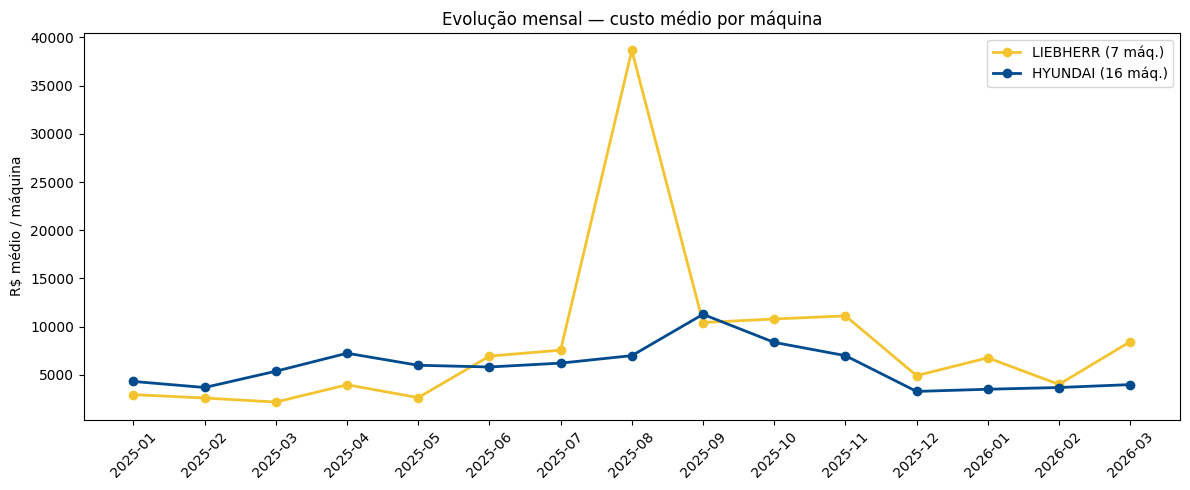

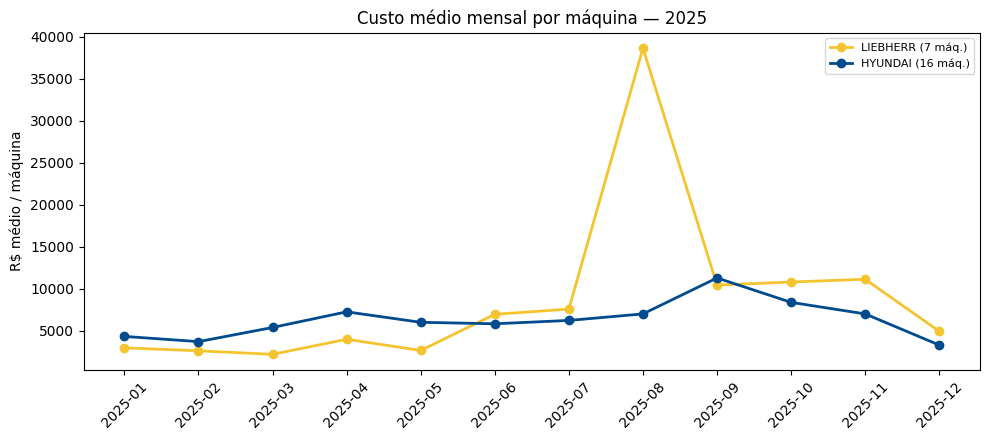

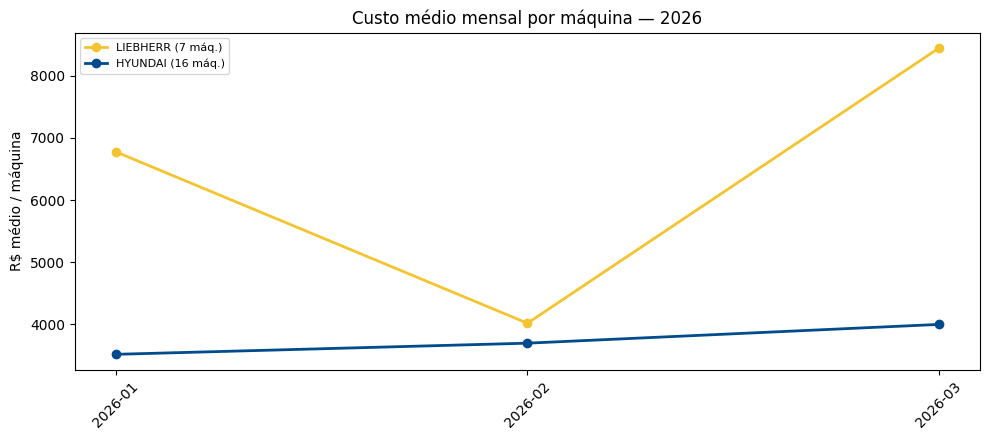

In [6]:
por_mes = (
  df_maq_graf.groupby(["mes_nf", "MARCA", "ano_nf"], observed=True)
  .agg(lanc=("valor_conta_num", "count"), volume=("gasto_abs", "sum"), liquido=("valor_conta_num", "sum"))
  .reset_index()
  .sort_values("mes_nf")
)
por_mes = adicionar_volume_por_maq(por_mes)
display(por_mes)

pivot_mes = por_mes.pivot(index="mes_nf", columns="MARCA", values="volume_por_maq").fillna(0)
display(Markdown(f"### Custo médio mensal por máquina (pivot) — {YLABEL_MAQ}"))
display(pivot_mes)

# Gráfico de linhas — série completa (normalizada)
fig, ax = plt.subplots(figsize=(12, 5))
for m in MARCAS_ALVO:
    if m in pivot_mes.columns:
        ax.plot(pivot_mes.index.astype(str), pivot_mes[m], marker="o", label=f"{m} ({QTD_PARQUE[m]} máq.)", color=CORES.get(m), lw=2)
ax.set_title("Evolução mensal — custo médio por máquina")
ax.set_ylabel(YLABEL_MAQ)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Gráficos de linhas — um por ano (normalizado)
for ano in sorted(por_mes["ano_nf"].dropna().unique()):
    sub = por_mes[por_mes["ano_nf"] == ano]
    piv_ano = sub.pivot(index="mes_nf", columns="MARCA", values="volume_por_maq").fillna(0)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for m in MARCAS_ALVO:
        if m in piv_ano.columns:
            ax.plot(piv_ano.index.astype(str), piv_ano[m], marker="o", label=f"{m} ({QTD_PARQUE[m]} máq.)", color=CORES.get(m), lw=2)
    ax.set_title(f"Custo médio mensal por máquina — {int(ano)}")
    ax.set_ylabel(YLABEL_MAQ)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Passo 6 — Distribuição mensal por máquina e Pareto

- **Estatísticas:** gasto mensal por máquina do parque (comparável entre 7 e 16 máquinas).
- **Pareto:** poucas máquinas costumam concentrar a maior parte do gasto do parque.

In [7]:
gasto_mensal_maq = (
  df_maq.groupby(["MARCA", "maq_id", "mes_nf"], observed=True)["gasto_abs"]
  .sum()
  .reset_index(name="gasto_mes")
)
display(Markdown("### Gasto mensal por máquina do parque (|valor_conta| agregado no mês)"))
display(gasto_mensal_maq.groupby("MARCA")["gasto_mes"].describe())


def pareto_maquinas(d: pd.DataFrame, marca: str, top_n: int = 15) -> pd.DataFrame:
  sub = (
    d[d["MARCA"] == marca]
    .groupby("maq_id", observed=True)["gasto_abs"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="volume")
  )
  sub["pct"] = sub["volume"] / sub["volume"].sum() * 100
  sub["pct_acum"] = sub["pct"].cumsum()
  return sub.head(top_n)


for marca in MARCAS_ALVO:
  display(Markdown(f"#### Pareto — {marca} (parque {QTD_PARQUE[marca]} máq.)"))
  display(pareto_maquinas(df_maq, marca))

### Gasto mensal por máquina do parque (|valor_conta| agregado no mês)

,count,mean,std,min,25%,50%,75%,max
MARCA,,,,,,,,
HYUNDAI,199.00,"6,984.59","8,369.50",89.90,"1,676.01","4,563.14","9,127.69","78,025.17"
LIEBHERR,72.00,"12,062.54","23,170.58",148.73,"2,370.95","6,774.10","14,473.12","187,955.22"


#### Pareto — LIEBHERR (parque 7 máq.)

,maq_id,volume,pct,pct_acum
0,EHL0043,"348,200.64",40.09,40.09
1,EHL0028,"251,326.47",28.94,69.03
2,EHL0014,"113,061.83",13.02,82.05
3,EHL0042,"92,821.28",10.69,92.74
4,EHL0041,"48,269.80",5.56,98.29
5,EHL0013,"14,422.57",1.66,99.95
6,EHL0070,400.00,0.05,100.00


#### Pareto — HYUNDAI (parque 16 máq.)

,maq_id,volume,pct,pct_acum
0,EHH0044,"231,877.74",16.68,16.68
1,EHH0038,"170,544.78",12.27,28.95
2,EHH0019,"136,469.54",9.82,38.77
3,EHH0040,"135,508.92",9.75,48.52
4,EHH0036,"104,508.57",7.52,56.04
5,EHH0004,"94,976.35",6.83,62.87
6,EHH0007,"91,045.38",6.55,69.42
7,EHH0039,"88,744.62",6.38,75.81
8,EHH0008,"86,877.24",6.25,82.06
9,EHH0009,"75,759.34",5.45,87.51


## Passo 7 — Gráficos

Comparativos Liebherr × Hyundai em **custo médio por máquina**. Figuras em `outputs/figuras/liebherr_hyundai/`.

> **Filtro:** gráficos usam `df_maq_graf` — exclui conta **7.4.5 (ISS)**. Tabelas e KPIs mantêm a base completa.

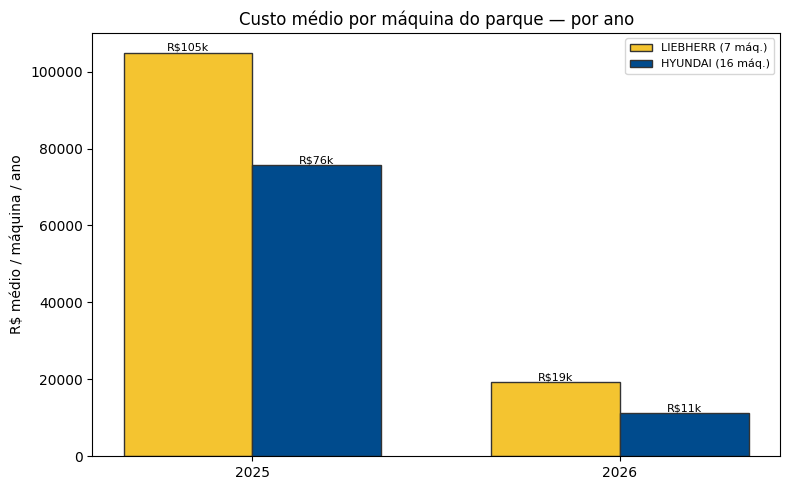

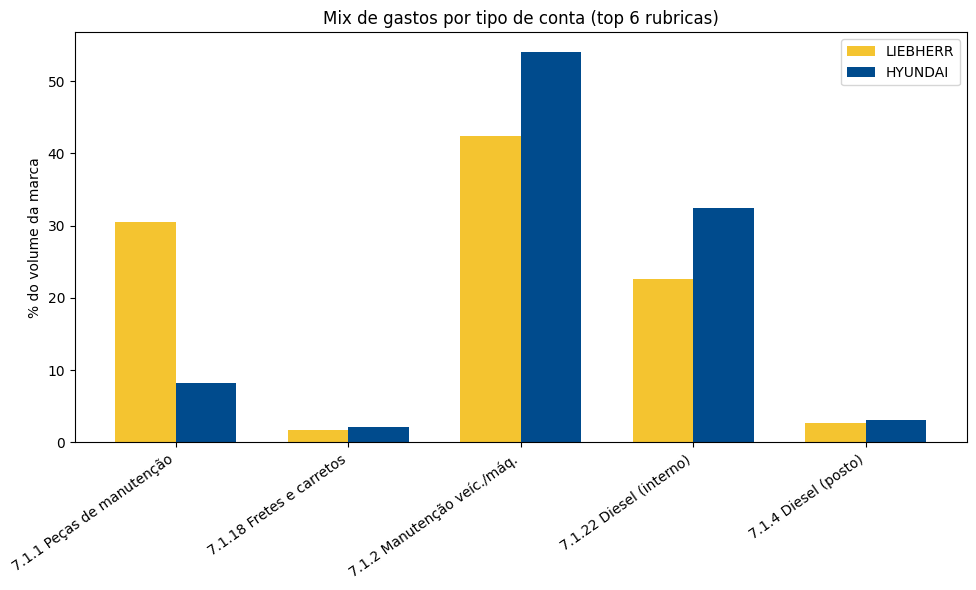

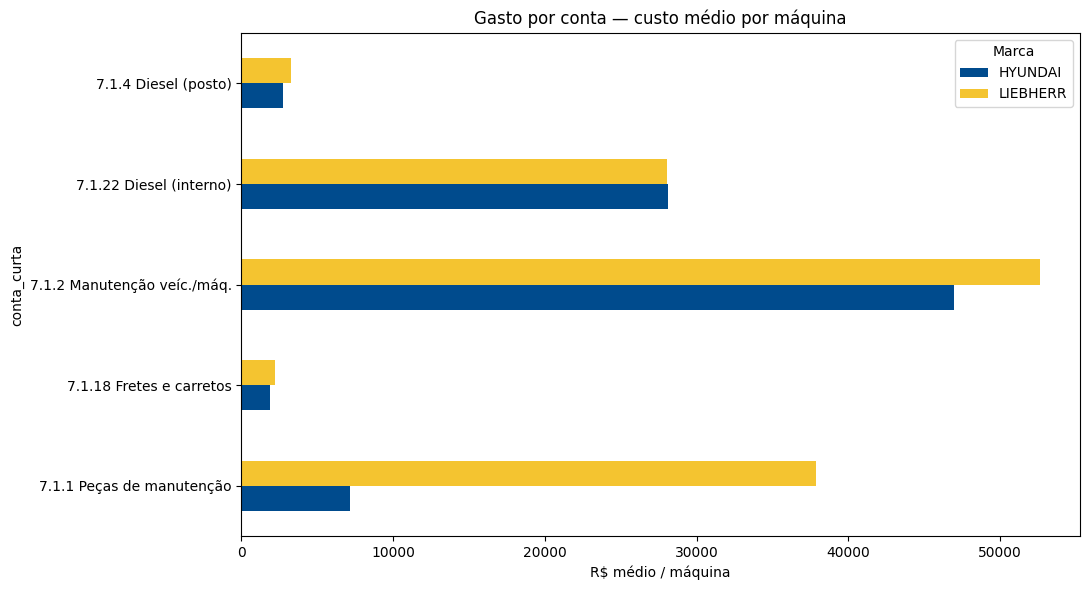

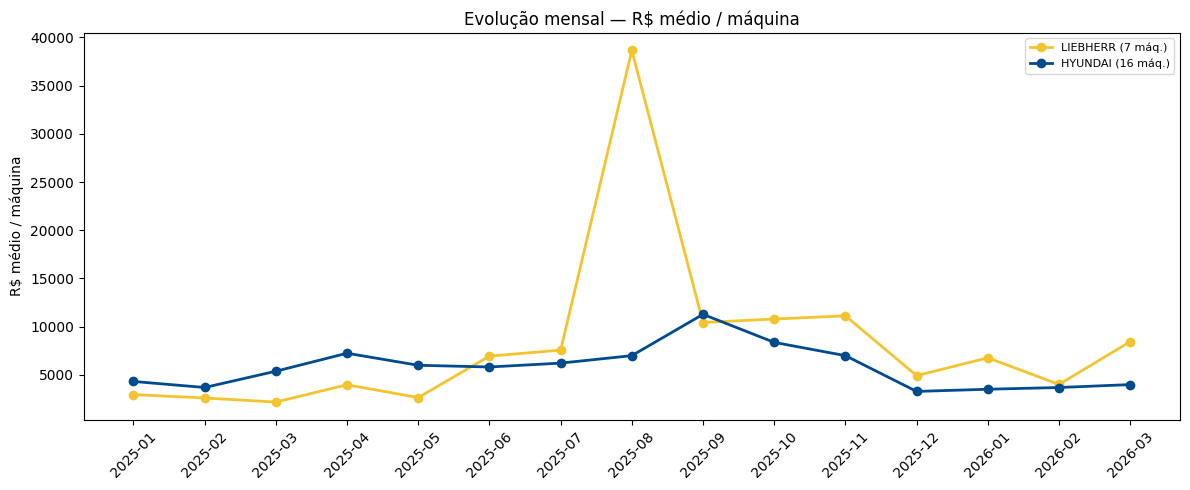

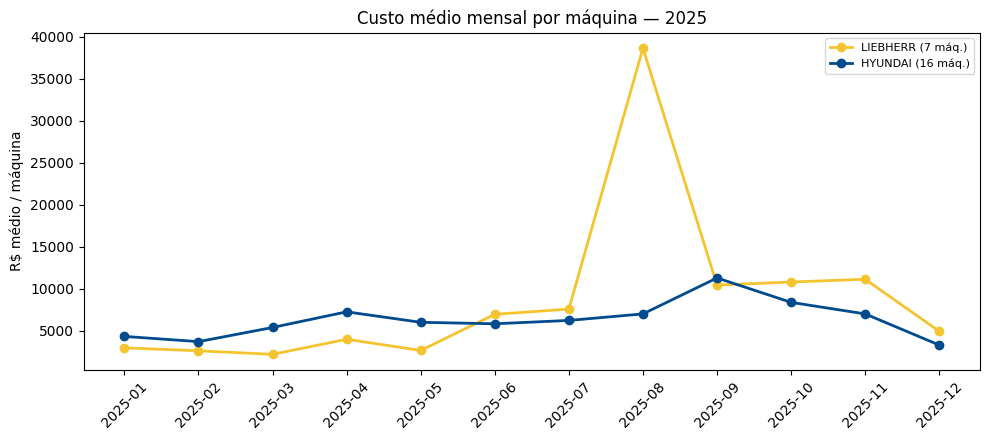

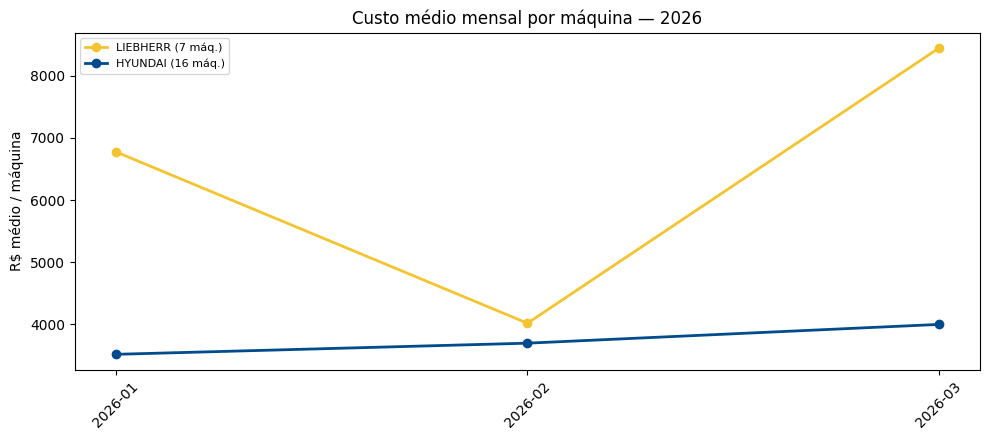

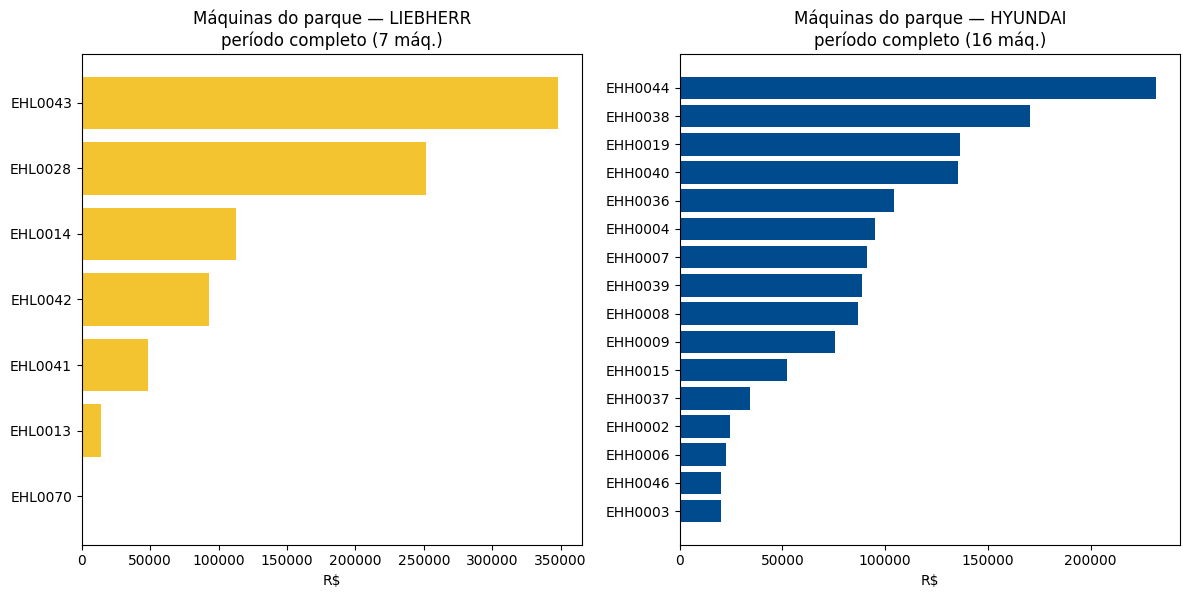

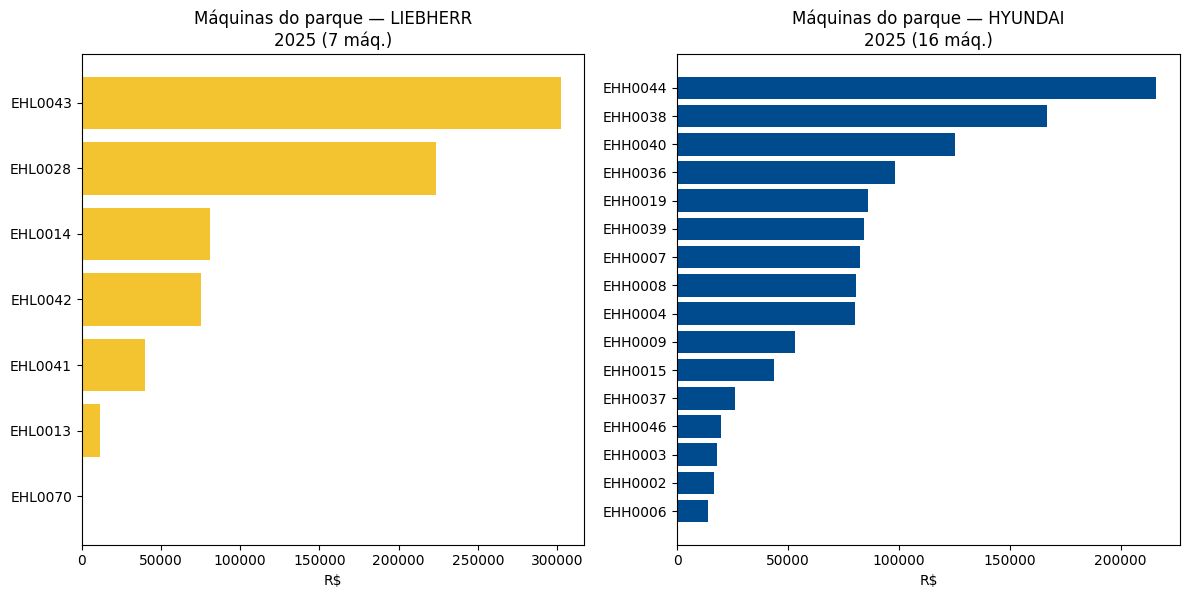

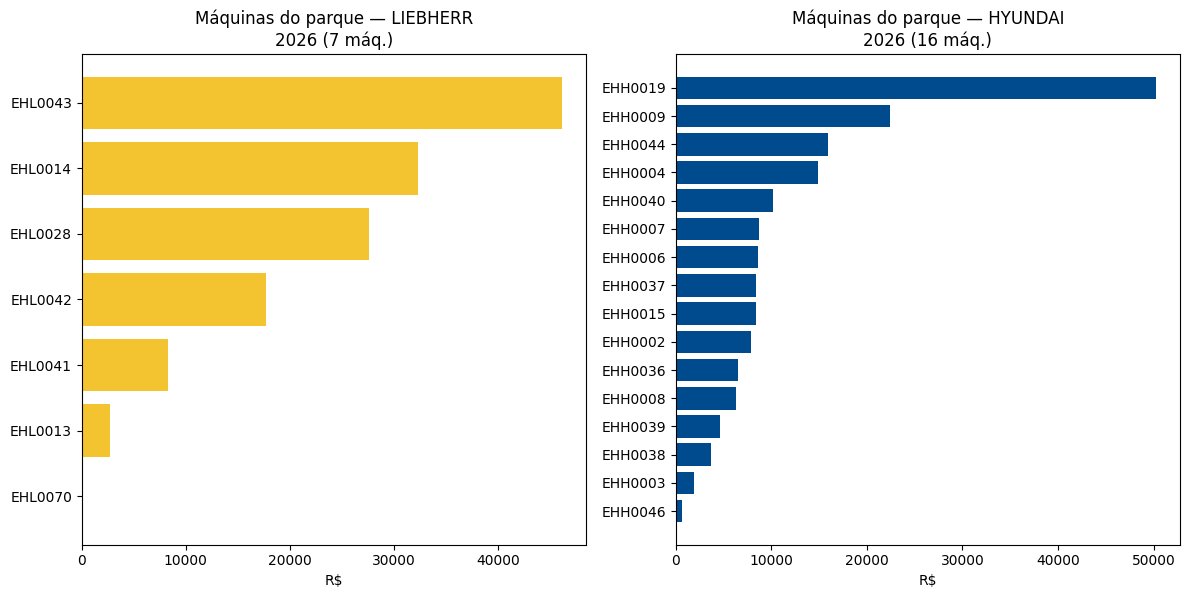

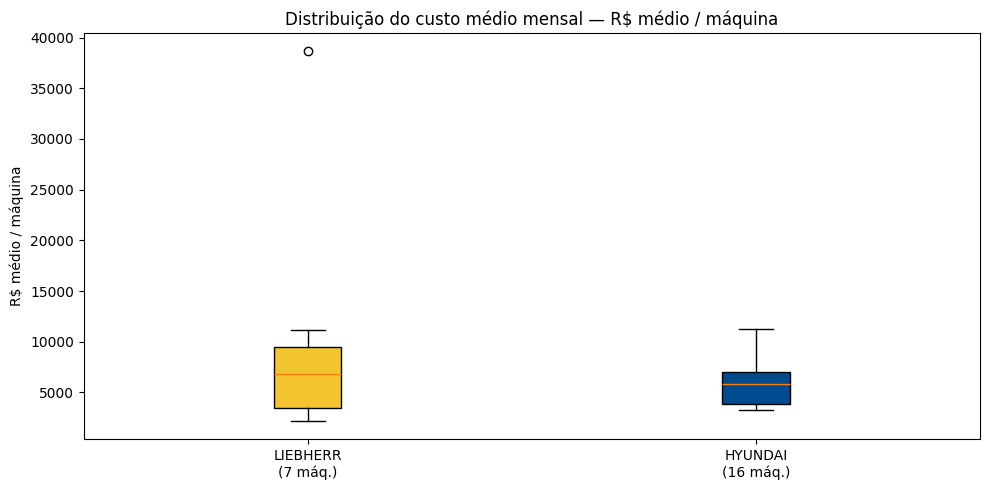

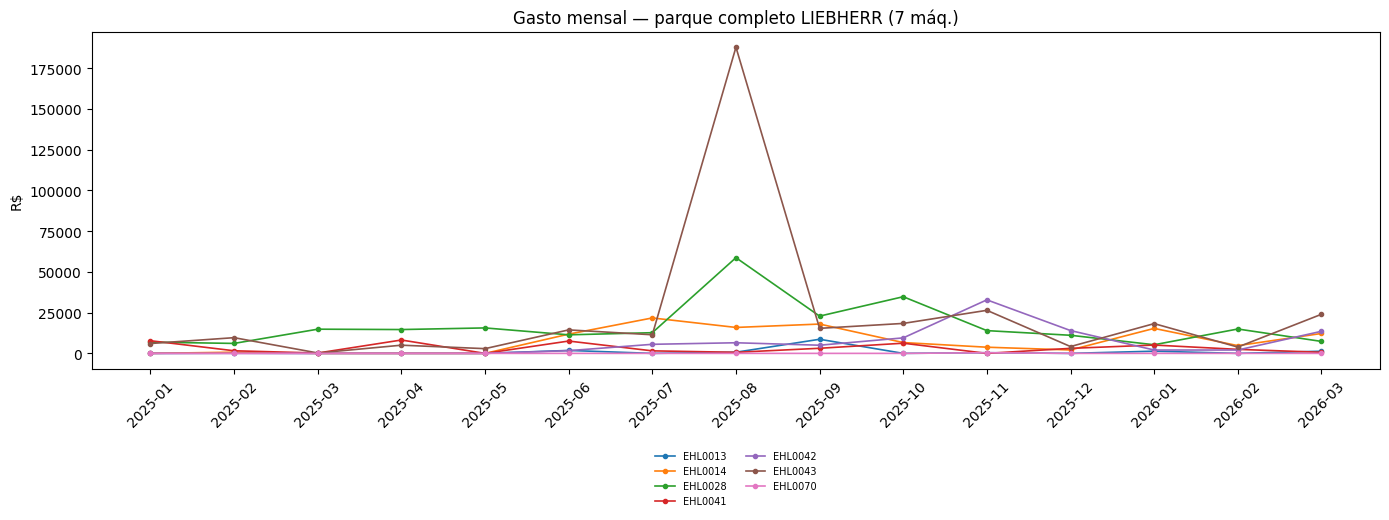

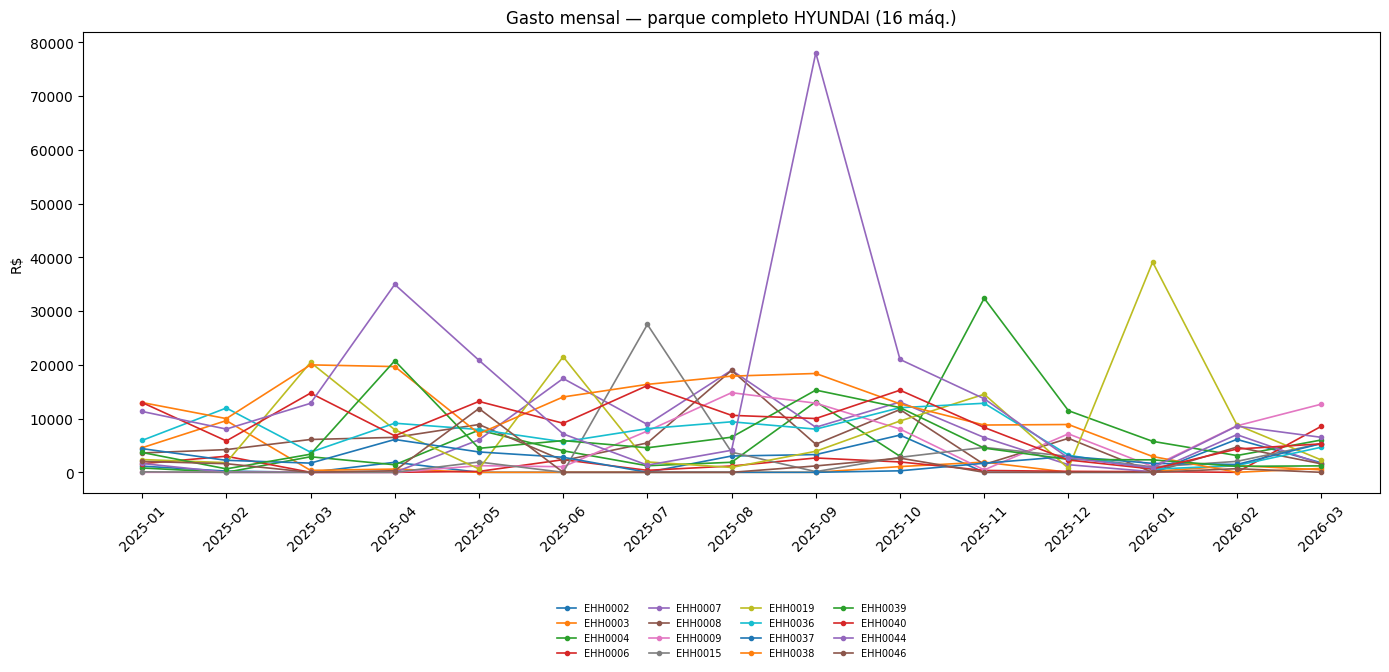

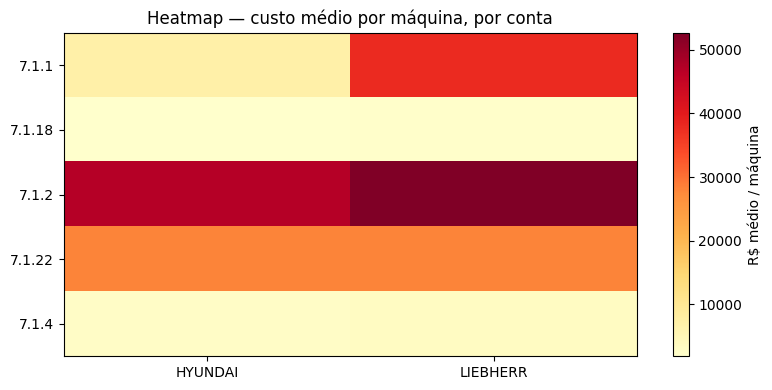

Figuras salvas em: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\figuras\liebherr_hyundai


In [8]:
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 10})

# ── Base dos gráficos: sem ISS (7.4.5) ───────────────────────────────────────
_dg = df_maq_graf

por_ano = (
    por_ano.drop(columns=["volume_parque", "custo_por_maquina_parque"], errors="ignore")
    .merge(
        _dg.groupby(["MARCA", "ano_nf"], observed=True)["gasto_abs"]
        .sum()
        .reset_index(name="volume_parque"),
        on=["MARCA", "ano_nf"],
        how="left",
    )
)
por_ano["volume_parque"] = por_ano["volume_parque"].fillna(0)
por_ano["custo_por_maquina_parque"] = por_ano["volume_parque"] / por_ano["parque"]

por_conta = adicionar_volume_por_maq(
    _dg.groupby(["MARCA", "cod_conta", "conta"], observed=True)
    .agg(qtd=("valor_conta_num", "count"), liquido=("valor_conta_num", "sum"), volume=("gasto_abs", "sum"))
    .reset_index()
    .sort_values(["MARCA", "volume"], ascending=[True, False])
)

por_mes = adicionar_volume_por_maq(
    _dg.groupby(["mes_nf", "MARCA", "ano_nf"], observed=True)
    .agg(lanc=("valor_conta_num", "count"), volume=("gasto_abs", "sum"), liquido=("valor_conta_num", "sum"))
    .reset_index()
    .sort_values("mes_nf")
)
pivot_mes = por_mes.pivot(index="mes_nf", columns="MARCA", values="volume_por_maq").fillna(0)

por_maquina = (
    _dg.groupby(["MARCA", "maq_id"], observed=True)
    .agg(
        lanc=("valor_conta_num", "count"),
        liquido=("valor_conta_num", "sum"),
        volume=("gasto_abs", "sum"),
        ticket_medio=("gasto_abs", "mean"),
        meses_com_lanc=("mes_nf", "nunique"),
    )
    .reset_index()
    .sort_values(["MARCA", "volume"], ascending=[True, False])
)

por_maquina_mes = (
    _dg.groupby(["MARCA", "maq_id", "ano_nf", "mes_nf"], observed=True)
    .agg(lanc=("valor_conta_num", "count"), volume=("gasto_abs", "sum"), media_lanc=("gasto_abs", "mean"))
    .reset_index()
    .sort_values(["MARCA", "maq_id", "mes_nf"])
)

ranking_maquinas_geral = ranking_maquinas_parque(_dg)
por_maquina_ano = pd.concat(
    [ranking_maquinas_parque(_dg, ano=a) for a in anos_maquina],
    ignore_index=True,
)

marcas_ord = [m for m in MARCAS_ALVO if m in df["MARCA"].unique()]
cores = [CORES.get(m, "#7f8c8d") for m in marcas_ord]

# 7.1 — Custo médio por máquina do parque, por ano
anos_ord = sorted(por_ano["ano_nf"].dropna().unique())
piv_ano_maq = por_ano.pivot(index="ano_nf", columns="MARCA", values="custo_por_maquina_parque").reindex(columns=marcas_ord)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(anos_ord))
w = 0.35
for i, m in enumerate(marcas_ord):
    if m not in piv_ano_maq.columns:
        continue
    vals = piv_ano_maq.loc[anos_ord, m].values
    bars = ax.bar(x + i * w, vals, width=w, label=f"{m} ({QTD_PARQUE[m]} máq.)", color=CORES.get(m), edgecolor="#333")
    for b, v in zip(bars, vals):
        if v > 0:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"R${v/1e3:.0f}k", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + w / 2)
ax.set_xticklabels([str(int(a)) for a in anos_ord])
ax.set_title("Custo médio por máquina do parque — por ano")
ax.set_ylabel(YLABEL_MAQ + " / ano")
ax.legend(fontsize=8)
plt.tight_layout()
p1 = OUT_FIG / "01_volume_por_ano.png"
fig.savefig(p1, dpi=130)
plt.show()

# Rótulos legíveis no eixo (evita truncar nomes como "DIESEL (INTERNO)")
ROTULOS_CONTA = {
    "7.1.1": "7.1.1 Peças de manutenção",
    "7.1.18": "7.1.18 Fretes e carretos",
    "7.1.2": "7.1.2 Manutenção veíc./máq.",
    "7.1.22": "7.1.22 Diesel (interno)",
    "7.1.4": "7.1.4 Diesel (posto)",
}


def rotulo_conta_grafico(cod: str, conta: str) -> str:
    cod = str(cod).strip()
    if cod in ROTULOS_CONTA:
        return ROTULOS_CONTA[cod]
    return f"{cod} {str(conta)[:35]}"


# 7.2 — Composição por conta (empilhado 100%)
top_contas = (
  por_conta.groupby("conta", observed=True)["volume"].sum().nlargest(6).index.tolist()
)
comp = por_conta[por_conta["conta"].isin(top_contas)].copy()
comp["conta_curta"] = comp.apply(lambda r: rotulo_conta_grafico(r["cod_conta"], r["conta"]), axis=1)
pivot_comp = comp.pivot(index="conta_curta", columns="MARCA", values="volume").fillna(0)
pivot_pct = pivot_comp.div(pivot_comp.sum(axis=0), axis=1) * 100
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pivot_pct))
w = 0.35
for i, m in enumerate(marcas_ord):
  if m in pivot_pct.columns:
    ax.bar(x + i * w, pivot_pct[m].values, width=w, label=m, color=CORES.get(m))
ax.set_xticks(x + w / 2)
ax.set_xticklabels(pivot_pct.index, rotation=35, ha="right")
ax.set_ylabel("% do volume da marca")
ax.set_title("Mix de gastos por tipo de conta (top 6 rubricas)")
ax.legend()
plt.tight_layout()
p2 = OUT_FIG / "02_mix_contas_pct.png"
fig.savefig(p2, dpi=130)
plt.show()

# 7.3 — Gasto por conta, normalizado por máquina do parque
fig, ax = plt.subplots(figsize=(11, 6))
pivot_vol = comp.pivot(index="conta_curta", columns="MARCA", values="volume_por_maq").fillna(0)
pivot_vol.plot(kind="barh", ax=ax, color=[CORES.get(m) for m in pivot_vol.columns])
ax.set_title(f"Gasto por conta — custo médio por máquina")
ax.set_xlabel(YLABEL_MAQ)
ax.legend(title="Marca")
plt.tight_layout()
p3 = OUT_FIG / "03_volume_por_conta.png"
fig.savefig(p3, dpi=130)
plt.show()

# 7.4 — Série mensal normalizada (linhas) — arquivo por ano
if len(pivot_mes) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    for m in marcas_ord:
        if m in pivot_mes.columns:
            ax.plot(pivot_mes.index.astype(str), pivot_mes[m], marker="o", label=f"{m} ({QTD_PARQUE[m]} máq.)", color=CORES.get(m), lw=2)
    ax.set_title(f"Evolução mensal — {YLABEL_MAQ}")
    ax.set_ylabel(YLABEL_MAQ)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
    plt.tight_layout()
    p4 = OUT_FIG / "04_serie_mensal.png"
    fig.savefig(p4, dpi=130)
    plt.show()
    for ano in anos_ord:
        sub = por_mes[por_mes["ano_nf"] == ano]
        piv_a = sub.pivot(index="mes_nf", columns="MARCA", values="volume_por_maq").fillna(0)
        fig, ax = plt.subplots(figsize=(10, 4.5))
        for m in marcas_ord:
            if m in piv_a.columns:
                ax.plot(piv_a.index.astype(str), piv_a[m], marker="o", label=f"{m} ({QTD_PARQUE[m]} máq.)", color=CORES.get(m), lw=2)
        ax.set_title(f"Custo médio mensal por máquina — {int(ano)}")
        ax.set_ylabel(YLABEL_MAQ)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=8)
        plt.tight_layout()
        fig.savefig(OUT_FIG / f"04_serie_mensal_{int(ano)}.png", dpi=130)
        plt.show()

# 7.5 — Todas as máquinas do parque (geral + por ano)
def plot_maquinas_parque(df_rank: pd.DataFrame, sufixo_titulo: str, outfile: Path) -> None:
  max_maq_parque = max(QTD_PARQUE[m] for m in marcas_ord)
  fig_h = max(6, max_maq_parque * 0.38)
  fig, axes = plt.subplots(1, len(marcas_ord), figsize=(6 * len(marcas_ord), fig_h), squeeze=False)
  for ax, marca in zip(axes[0], marcas_ord):
    top = df_rank[df_rank["MARCA"] == marca].head(16)
    ax.barh(top["maq_id"].astype(str), top["volume"], color=CORES.get(marca))
    ax.invert_yaxis()
    ax.set_title(f"Máquinas do parque — {marca}\n{sufixo_titulo} ({len(top)} máq.)")
    ax.set_xlabel("R$")
  plt.tight_layout()
  fig.savefig(outfile, dpi=130)
  plt.show()


plot_maquinas_parque(ranking_maquinas_geral, "período completo", OUT_FIG / "05_top_maquinas.png")
for ano in anos_maquina:
  rank_ano = por_maquina_ano[por_maquina_ano["ano_nf"] == ano]
  plot_maquinas_parque(rank_ano, str(ano), OUT_FIG / f"05_top_maquinas_{ano}.png")

# 7.6 — Boxplot: distribuição do gasto mensal por máquina do parque
fig, ax = plt.subplots()
data_box = [por_mes.loc[por_mes["MARCA"] == m, "volume_por_maq"].dropna().values for m in marcas_ord]
bp = ax.boxplot(data_box, tick_labels=[f"{m}\n({QTD_PARQUE[m]} máq.)" for m in marcas_ord], patch_artist=True)
for patch, m in zip(bp["boxes"], marcas_ord):
  patch.set_facecolor(CORES.get(m, "#ccc"))
ax.set_title(f"Distribuição do custo médio mensal — {YLABEL_MAQ}")
ax.set_ylabel(YLABEL_MAQ)
plt.tight_layout()
p6 = OUT_FIG / "06_boxplot_lancamentos.png"
fig.savefig(p6, dpi=130)
plt.show()

# 7.9 — Gasto mensal de TODAS as máquinas do parque por marca (linhas)
for marca in marcas_ord:
    ids_parque = PARQUE_MAQUINAS.get(marca, [])
    sub = por_maquina_mes[por_maquina_mes["MARCA"] == marca]
    if sub.empty:
        continue
    piv_m = (
        sub.pivot(index="mes_nf", columns="maq_id", values="volume")
        .reindex(columns=ids_parque)
        .fillna(0)
        .sort_index()
    )
    n_maq = len(ids_parque)
    fig, ax = plt.subplots(figsize=(14, 7 if n_maq > 10 else 5.5))
    for col in piv_m.columns:
        ax.plot(piv_m.index.astype(str), piv_m[col], marker="o", markersize=3, label=col, lw=1.2)
    ax.set_title(f"Gasto mensal — parque completo {marca} ({n_maq} máq.)")
    ax.set_ylabel("R$")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(
        fontsize=7,
        ncol=min(4, max(2, (n_maq + 3) // 4)),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        frameon=False,
    )
    plt.tight_layout()
    fig.savefig(OUT_FIG / f"09_mes_maquinas_{marca.lower()}.png", dpi=130, bbox_inches="tight")
    plt.show()

# 7.8 — Heatmap conta × marca (R$ / máquina do parque)
hm = por_conta.pivot(index="cod_conta", columns="MARCA", values="volume_por_maq").fillna(0)
if len(hm) > 0:
  fig, ax = plt.subplots(figsize=(8, max(4, len(hm) * 0.45)))
  im = ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
  ax.set_xticks(range(len(hm.columns)))
  ax.set_xticklabels(hm.columns)
  ax.set_yticks(range(len(hm.index)))
  ax.set_yticklabels(hm.index)
  ax.set_title(f"Heatmap — custo médio por máquina, por conta")
  plt.colorbar(im, ax=ax, label=YLABEL_MAQ)
  plt.tight_layout()
  p8 = OUT_FIG / "08_heatmap_contas.png"
  fig.savefig(p8, dpi=130)
  plt.show()

print("Figuras salvas em:", OUT_FIG.resolve())

## Passo 8 — Síntese de insights e exportação

In [9]:
def gerar_insights(
  d: pd.DataFrame,
  kpi_df: pd.DataFrame,
  conta_df: pd.DataFrame,
  gasto_local_df: pd.DataFrame | None = None,
) -> list[str]:
  linhas: list[str] = []
  if len(MARCAS_ALVO) != 2:
    return ["Ajuste MARCAS_ALVO para duas marcas para insights comparativos automáticos."]
  a, b = MARCAS_ALVO
  pa, pb = QTD_PARQUE[a], QTD_PARQUE[b]
  ca = kpi_df.loc["custo médio/máquina (parque)", a]
  cb = kpi_df.loc["custo médio/máquina (parque)", b]
  maior_custo = a if ca >= cb else b
  menor_custo = b if maior_custo == a else a
  diff_custo = abs(ca - cb) / min(ca, cb) * 100 if min(ca, cb) else np.nan
  linhas.append(
    f"**Custo médio/máquina (comparativo justo):** {maior_custo} custa **{diff_custo:.1f}%** a mais "
    f"(R$ {max(ca, cb):,.0f}/máq vs R$ {min(ca, cb):,.0f}/máq; "
    f"parque: {pa} vs {pb} máquinas)."
  )
  va = kpi_df.loc["volume gasto (|valor|)", a]
  vb = kpi_df.loc["volume gasto (|valor|)", b]
  maior_vol = a if va >= vb else b
  menor_vol = b if maior_vol == a else a
  linhas.append(
    f"**Volume absoluto (contexto):** {maior_vol} tem maior gasto total "
    f"(R$ {max(va, vb):,.0f} vs R$ {min(va, vb):,.0f}) — reflexo do tamanho do parque."
  )
  for _, row in por_ano.sort_values(["ano_nf", "MARCA"]).iterrows():
    linhas.append(
      f"**{int(row['ano_nf'])} — {row['MARCA']}:** volume R$ {row['volume']:,.0f} "
      f"(custo médio R$ {row['custo_por_maquina_parque']:,.0f}/máquina)."
    )
  def top_conta_marca(marca: str) -> pd.Series | None:
    sub = conta_df[conta_df["MARCA"] == marca]
    if sub.empty:
      return None
    ordem = "volume_por_maq" if "volume_por_maq" in sub.columns else "volume"
    return sub.sort_values(ordem, ascending=False).iloc[0]

  top_a = top_conta_marca(a)
  top_b = top_conta_marca(b)
  if top_a is not None and top_b is not None:
    va_maq = top_a.get("volume_por_maq", top_a["volume"] / pa)
    vb_maq = top_b.get("volume_por_maq", top_b["volume"] / pb)
    linhas.append(
      f"**Tipo dominante (R$/máq):** {a} → {top_a['cod_conta']} {top_a['conta'][:40]} "
      f"(R$ {va_maq:,.0f}/máq); {b} → {top_b['cod_conta']} {top_b['conta'][:40]} "
      f"(R$ {vb_maq:,.0f}/máq)."
    )
  # diferença de mix manutenção vs combustível
  def pct_conta(marca, cod):
    sub = conta_df[conta_df["MARCA"] == marca]
    tot = sub["volume"].sum()
    v = sub.loc[sub["cod_conta"] == cod, "volume"].sum()
    return v / tot * 100 if tot else 0

  linhas.append(
    f"**Mix manutenção (7.1.2):** {a} {pct_conta(a,'7.1.2'):.1f}% vs {b} {pct_conta(b,'7.1.2'):.1f}% do volume."
  )
  linhas.append(
    f"**Mix combustível (7.1.22+7.1.4):** {a} {pct_conta(a,'7.1.22')+pct_conta(a,'7.1.4'):.1f}% vs "
    f"{b} {pct_conta(b,'7.1.22')+pct_conta(b,'7.1.4'):.1f}%."
  )
  linhas.append(
    f"**Mix peças (7.1.1):** {a} {pct_conta(a,'7.1.1'):.1f}% vs {b} {pct_conta(b,'7.1.1'):.1f}%."
  )
  # concentração pareto
  for marca in MARCAS_ALVO:
    p = pareto_maquinas(d, marca, top_n=3)
    if len(p):
      linhas.append(
        f"**Concentração {marca}:** top 3 máquinas = {p['pct_acum'].iloc[min(2,len(p)-1)]:.0f}% do gasto "
        f"(líder: {p['maq_id'].iloc[0]})."
      )
  # custo por unidade de operação
  if gasto_local_df is not None and len(gasto_local_df):
    body = gasto_local_df.copy()
    tot_parque = body["Total"].sum()
    if tot_parque > 0:
      top = body.iloc[0]
      linhas.append(
        f"**Unidade com maior custo:** {top['Local']} — R$ {top['Total']:,.0f} "
        f"({int(top['Máquinas'])} máq.; R$ {top['R$/máq']:,.0f}/máq)."
      )
      top3 = body.head(3)
      share = top3["Total"].sum() / tot_parque * 100
      det = "; ".join(f"{r['Local']} (R$ {r['Total']:,.0f})" for _, r in top3.iterrows())
      linhas.append(f"**Top 3 unidades:** {det} — {share:.0f}% do gasto do parque.")
      intensa = body.sort_values("R$/máq", ascending=False).iloc[0]
      if intensa["Local"] != top["Local"]:
        linhas.append(
          f"**Maior intensidade (R$/máq):** {intensa['Local']} — "
          f"R$ {intensa['R$/máq']:,.0f}/máq ({int(intensa['Máquinas'])} máq.)."
        )
      a, b = MARCAS_ALVO
      va = float(top.get(a, 0))
      vb = float(top.get(b, 0))
      if va > 0 or vb > 0:
        dom = a if va >= vb else b
        linhas.append(
          f"**Na unidade líder ({top['Local']}):** {a} R$ {va:,.0f} vs {b} R$ {vb:,.0f} "
          f"(predomina {dom})."
        )
  return linhas


insights = gerar_insights(df, kpi, por_conta, gasto_por_local)
display(Markdown("### Insights gerados"))
for i, txt in enumerate(insights, 1):
  display(Markdown(f"{i}. {txt}"))

def exportar_resumo_xlsx(path: Path) -> Path:
  """Grava o Excel; se o arquivo estiver aberto no Excel, usa cópia com timestamp."""
  from datetime import datetime

  def _gravar(dest: Path) -> None:
    with pd.ExcelWriter(dest, engine="openpyxl") as w:
      kpi.reset_index().rename(columns={"index": "indicador"}).to_excel(w, sheet_name="kpi", index=False)
      por_conta.to_excel(w, sheet_name="por_conta", index=False)
      share_conta.to_excel(w, sheet_name="share_conta", index=False)
      por_maquina.to_excel(w, sheet_name="por_maquina", index=False)
      por_maquina_ano.to_excel(w, sheet_name="por_maquina_ano", index=False)
      ranking_maquinas_geral.to_excel(w, sheet_name="ranking_maquinas_geral", index=False)
      cadastro_parque.to_excel(w, sheet_name="cadastro_parque", index=False)
      resumo_local.to_excel(w, sheet_name="resumo_local", index=False)
      gasto_por_local.to_excel(w, sheet_name="gasto_por_local", index=False)
      gasto_maquina_mes_wide.to_excel(w, sheet_name="gasto_maquina_mes_wide", index=False)
      por_maquina_mes.to_excel(w, sheet_name="por_maquina_mes", index=False)
      pd.DataFrame({"marca": MARCAS_ALVO, "maq_id": [", ".join(PARQUE_MAQUINAS[m]) for m in MARCAS_ALVO]}).to_excel(w, sheet_name="parque", index=False)
      por_divisao.to_excel(w, sheet_name="por_divisao", index=False)
      por_filial.to_excel(w, sheet_name="por_filial", index=False)
      por_mes.to_excel(w, sheet_name="por_mes", index=False)
      por_ano.to_excel(w, sheet_name="por_ano", index=False)
      pd.DataFrame({"insight": insights}).to_excel(w, sheet_name="insights", index=False)

  try:
    _gravar(path)
    return path
  except PermissionError:
    alt = path.with_name(f"{path.stem}_{datetime.now():%Y%m%d_%H%M%S}{path.suffix}")
    _gravar(alt)
    display(Markdown(
      f"**Aviso:** `{path.name}` está bloqueado (provavelmente aberto no Excel). "
      f"Exportado em `{alt.name}`. Feche o arquivo e rode a célula de novo para gravar no caminho padrão."
    ))
    return alt


OUT_XLSX = exportar_resumo_xlsx(OUT_TAB / "comparativo_liebherr_hyundai.xlsx")
print(f"Resumo exportado: {OUT_XLSX.resolve()}")

### Insights gerados

1. **Custo médio/máquina (comparativo justo):** LIEBHERR custa **42.8%** a mais (R$ 124,072/máq vs R$ 86,871/máq; parque: 7 vs 16 máquinas).

2. **Volume absoluto (contexto):** HYUNDAI tem maior gasto total (R$ 1,399,720 vs R$ 870,203) — reflexo do tamanho do parque.

3. **2025 — HYUNDAI:** volume R$ 1,220,373 (custo médio R$ 75,649/máquina).

4. **2025 — LIEBHERR:** volume R$ 733,840 (custo médio R$ 104,834/máquina).

...

13. **Unidade com maior custo:** Maringá — R$ 556,716 (5 máq.; R$ 111,343/máq).

14. **Top 3 unidades:** Maringá (R$ 556,716); Dourados (R$ 429,208); Prudente (R$ 349,489) — 59% do gasto do parque.

15. **Maior intensidade (R$/máq):** Dourados — R$ 143,069/máq (3 máq.).

16. **Na unidade líder (Maringá):** LIEBHERR R$ 348,601 vs HYUNDAI R$ 208,115 (predomina LIEBHERR).

Resumo exportado: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\tabelas\comparativo_liebherr_hyundai.xlsx


## Passo 9 — Exportar dados para o relatório LaTeX

Atualiza `*.tex` e copia figuras para `figuras/` (pasta local do LaTeX). Depois compile com `pdflatex main.tex` (ver README).

In [10]:
import importlib.util

OUT_LATEX = ROOT / "outputs" / "relatorios" / "comparativo_liebherr_hyundai"
_export_py = OUT_LATEX / "export_latex.py"
if not _export_py.exists():
    raise FileNotFoundError(_export_py)

spec = importlib.util.spec_from_file_location("export_latex", _export_py)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
dest = mod.exportar(OUT_XLSX)
print(f"Arquivos .tex atualizados em: {dest.resolve()}")
print("Figuras em:", (OUT_LATEX / "figuras").resolve())
print("Compile (WSL): cd outputs/relatorios/comparativo_liebherr_hyundai && pdflatex main.tex")

Figuras OK em: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\relatorios\comparativo_liebherr_hyundai\figuras (10 arquivos)
Arquivos .tex atualizados em: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\relatorios\comparativo_liebherr_hyundai
Figuras em: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\relatorios\comparativo_liebherr_hyundai\figuras
Compile (WSL): cd outputs/relatorios/comparativo_liebherr_hyundai && pdflatex main.tex


## Passo 10 — Dashboard Excel (apresentação ~10 min)

Alternativa ao PDF: planilha interativa com **Gasto por Local** (expandir Local → Marca → Máquina), tabela estilo pivot, gráficos embutidos e aba **Fonte_Dados** para Tabela Dinâmica / Slicers no Excel.

> Abra `outputs/tabelas/dashboard_liebherr_hyundai.xlsx` — comece pela aba **Apresentação**.

In [11]:
import importlib.util

_script = ROOT / "outputs" / "relatorios" / "comparativo_liebherr_hyundai" / "export_dashboard_excel.py"
_spec = importlib.util.spec_from_file_location("export_dashboard_excel", _script)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

OUT_DASHBOARD = _mod.exportar_dashboard(OUT_TAB / "dashboard_liebherr_hyundai.xlsx")
display(Markdown(f"**Dashboard Excel:** `{OUT_DASHBOARD.resolve()}`"))
display(Markdown(
    "Abas: **Apresentação** (KPIs + figuras) · **Gasto por Local** (drill-down) · "
    "**Resumo Local×Marca** · **Série mensal** (gráfico nativo) · **Fonte_Dados** (pivot) · **Como usar**"
))

**Dashboard Excel:** `C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\outputs\tabelas\dashboard_liebherr_hyundai.xlsx`

Abas: **Apresentação** (KPIs + figuras) · **Gasto por Local** (drill-down) · **Resumo Local×Marca** · **Série mensal** (gráfico nativo) · **Fonte_Dados** (pivot) · **Como usar**